# Bài 1: Titanic — Logistic Regression vs Linear Regression


## 0. Import & cấu hình

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

FIGDIR = "figs"                 # thư mục lưu hình để chèn vào slide
os.makedirs(FIGDIR, exist_ok=True)
NAVY, GOLD, CORAL = "#003580", "#E8A33D", "#EE6C4D"

## 1. Tải dữ liệu

In [2]:
try:
    raw = sns.load_dataset("titanic")
    SOURCE = "seaborn"
except Exception:
    raw = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
    SOURCE = "url"
print("Nguồn:", SOURCE, "| shape:", raw.shape)
raw.head()

Nguồn: seaborn | shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Task 1 — Loại bỏ cột rò rỉ (leakage) và cột dư thừa

In [3]:
# Chuẩn hóa tên cột về dạng Title-case thống nhất cho cả 2 nguồn
rename_map = {"survived":"Survived","pclass":"Pclass","sex":"Sex","age":"Age",
              "sibsp":"SibSp","parch":"Parch","fare":"Fare","embarked":"Embarked",
              "cabin":"Cabin"}
raw = raw.rename(columns={c: rename_map.get(c.lower(), c) for c in raw.columns})

# GIỮ LẠI phần cabin/deck để phân tích missing ở Task 3 (sẽ bỏ sau)
leaky_derived = [c for c in ["alive", "adult_male", "who", "class",
                             "embark_town", "alone"] if c in raw.columns]
print("Cột rò rỉ/dẫn xuất sẽ loại:", leaky_derived)
df = raw.drop(columns=leaky_derived)
print("Còn lại:", list(df.columns))

Cột rò rỉ/dẫn xuất sẽ loại: ['alive', 'adult_male', 'who', 'class', 'embark_town', 'alone']
Còn lại: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'deck']


## 3. Task 2 — `shape`, `info`, `describe`

In [4]:
print("Biến mục tiêu: 'Survived' |", df.shape[0], "mẫu,", df.shape[1], "cột")
df.info()

Biến mục tiêu: 'Survived' | 891 mẫu, 9 cột
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    int64   
 2   Sex       891 non-null    str     
 3   Age       714 non-null    float64 
 4   SibSp     891 non-null    int64   
 5   Parch     891 non-null    int64   
 6   Fare      891 non-null    float64 
 7   Embarked  889 non-null    str     
 8   deck      203 non-null    category
dtypes: category(1), float64(2), int64(4), str(2)
memory usage: 57.0 KB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
Embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deck,203,7,C,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Task 3 — Missing Value + đề xuất xử lý

Cột `deck`/`Cabin` thiếu rất nhiều (~77%) — sẽ **loại bỏ**. `Age` thiếu vừa phải → điền **median**. `Embarked` thiếu rất ít → điền **mode**.

deck        77.2
Age         19.9
Embarked     0.2
dtype: float64


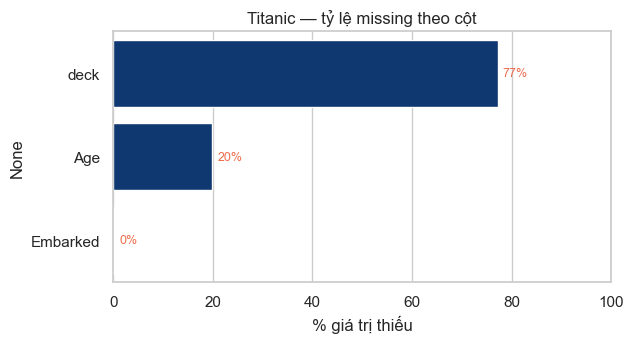

In [6]:
miss = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
miss = miss[miss > 0]
print(miss)

# Hình cho slide: % missing theo cột
plt.figure(figsize=(6.5, 3.6))
sns.barplot(x=miss.values, y=miss.index, color=NAVY)
for i, v in enumerate(miss.values):
    plt.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=9, color=CORAL)
plt.xlabel("% giá trị thiếu"); plt.title("Titanic — tỷ lệ missing theo cột")
plt.xlim(0, 100); plt.tight_layout()
plt.savefig(f"{FIGDIR}/titanic_missing.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Loại cột thiếu quá nhiều (deck/Cabin) khỏi tập đặc trưng
for c in ["deck", "Cabin"]:
    if c in df.columns:
        df = df.drop(columns=c)
print("Sau khi bỏ cột thiếu nặng:", list(df.columns))

Sau khi bỏ cột thiếu nặng: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


## 5. Task 4 — Outlier + **quyết định xử lý**

Không chỉ phát hiện, phải **quyết định** làm gì với chúng.

In [8]:
def iqr_outliers(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < low) | (s > high)).sum(), (low, high)

for col in ["Age", "Fare"]:
    n_out, (lo, hi) = iqr_outliers(df[col].dropna())
    z = np.abs(stats.zscore(df[col].dropna()))
    print(f"{col:5s}: IQR outliers = {n_out:3d} (ngoài [{lo:.1f}, {hi:.1f}]) | Z-score(>3) = {(z>3).sum()}")

Age  : IQR outliers =  11 (ngoài [-6.7, 64.8]) | Z-score(>3) = 2
Fare : IQR outliers = 116 (ngoài [-26.7, 65.6]) | Z-score(>3) = 20


**Quyết định:** `Fare` có nhiều outlier theo IQR, nhưng đó là **vé hạng nhất có thật** (giá trị hợp lệ), không phải lỗi nhập liệu. → **Giữ lại** và dùng **RobustScaler** (bền vững với outlier) thay vì xóa. `Age` outlier không đáng kể.

## 6. Task 5 — Trực quan hóa (lưu hình cho slide)

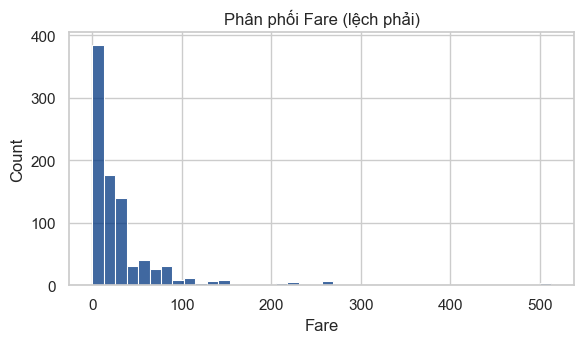

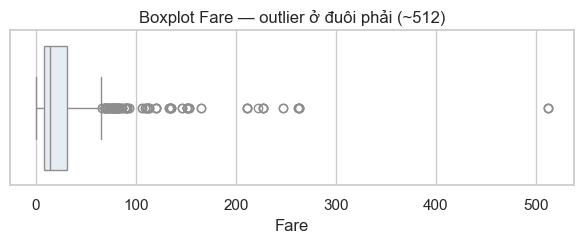

In [9]:
# (a) Histogram Fare — lệch phải rõ rệt
plt.figure(figsize=(6, 3.6))
sns.histplot(df["Fare"], bins=40, color=NAVY)
plt.title("Phân phối Fare (lệch phải)"); plt.tight_layout()
plt.savefig(f"{FIGDIR}/titanic_fare_hist.png", dpi=150, bbox_inches="tight")
plt.show()

# (b) Boxplot Fare — chỉ ra outlier ~512
plt.figure(figsize=(6, 2.6))
sns.boxplot(x=df["Fare"], color="#E4ECF5")
plt.title("Boxplot Fare — outlier ở đuôi phải (~512)"); plt.tight_layout()
plt.savefig(f"{FIGDIR}/titanic_fare_box.png", dpi=150, bbox_inches="tight")
plt.show()

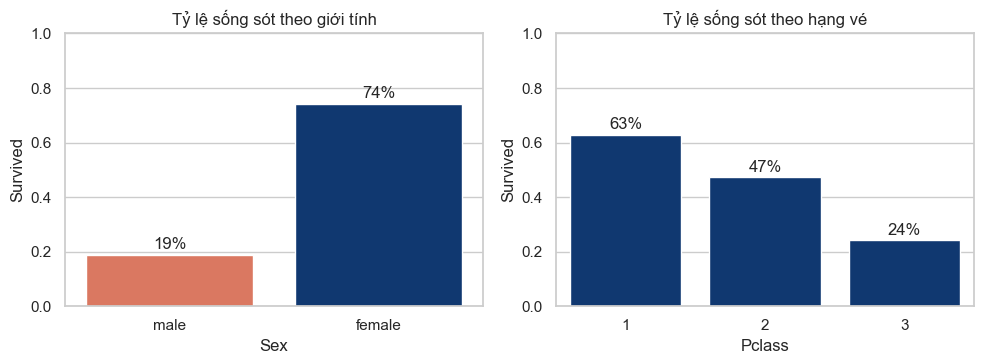

Sống sót:  nữ = 74%  vs  nam = 19%


In [10]:
# (c) Bivariate: tỷ lệ sống sót theo Sex và Pclass
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
sns.barplot(data=df, x="Sex", y="Survived", hue="Sex", legend=False, ax=axes[0], errorbar=None, palette=[CORAL, NAVY])
axes[0].set_title("Tỷ lệ sống sót theo giới tính"); axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.0%}", (p.get_x()+p.get_width()/2, p.get_height()+0.02), ha="center")
sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1], errorbar=None, color=NAVY)
axes[1].set_title("Tỷ lệ sống sót theo hạng vé"); axes[1].set_ylim(0, 1)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.0%}", (p.get_x()+p.get_width()/2, p.get_height()+0.02), ha="center")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/titanic_survival.png", dpi=150, bbox_inches="tight")
plt.show()

print("Sống sót:  nữ = {:.0%}  vs  nam = {:.0%}".format(
    df.loc[df.Sex=="female","Survived"].mean(), df.loc[df.Sex=="male","Survived"].mean()))

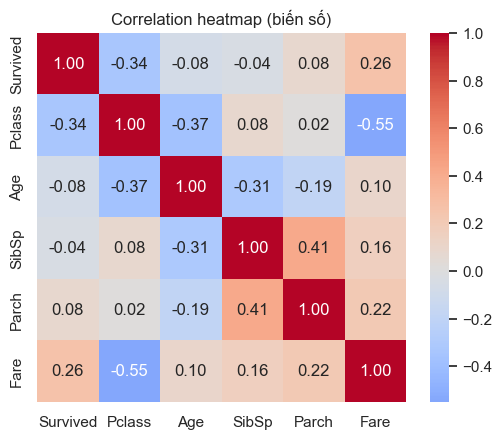

In [11]:
# (d) Correlation heatmap (chỉ biến số, sau khi đã bỏ cột leaky)
num = df.select_dtypes("number")
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap (biến số)"); plt.tight_layout()
plt.savefig(f"{FIGDIR}/titanic_corr.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Task 6 — Chia tập TRƯỚC (chống data leakage)

In [12]:
X = df.drop(columns="Survived")
y = df["Survived"]

# 70 / 15 / 15, stratify để giữ tỷ lệ hai lớp
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.1765, random_state=42, stratify=y_tmp)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  tỷ lệ Survived ({name}): {yy.mean():.3f}")

Train: (623, 7) | Val: (134, 7) | Test: (134, 7)
  tỷ lệ Survived (train): 0.384
  tỷ lệ Survived (val): 0.388
  tỷ lệ Survived (test): 0.381


## 8. Task 7 — Pipeline tiền xử lý (impute → encode → scale), fit CHỈ trên train

In [13]:
num_cols = ["Age", "SibSp", "Parch", "Fare"]
cat_cols = ["Sex", "Embarked"]
ord_cols = ["Pclass"]

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler",  RobustScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore"))])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)                       # fit CHỈ trên train
Xtr = preprocess.transform(X_train)
Xva = preprocess.transform(X_val)
Xte = preprocess.transform(X_test)
print("Sau tiền xử lý — train:", Xtr.shape, "| val:", Xva.shape, "| test:", Xte.shape)
print("Tên cột sau biến đổi:", list(preprocess.get_feature_names_out()))

Sau tiền xử lý — train: (623, 8) | val: (134, 8) | test: (134, 8)
Tên cột sau biến đổi: ['num__Age', 'num__SibSp', 'num__Parch', 'num__Fare', 'cat__Sex_male', 'cat__Embarked_Q', 'cat__Embarked_S', 'ord__Pclass']


## 9. Bài 1 — Logistic Regression (sklearn) & so sánh với Linear Regression

In [14]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

print("Xtr:", Xtr.shape, "| Xte:", Xte.shape)
print("y_train phân bố:\n", y_train.value_counts(normalize=True).round(3))

Xtr: (623, 8) | Xte: (134, 8)
y_train phân bố:
 Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


### 9.1. Huấn luyện Logistic Regression

`LogisticRegression` học một siêu phẳng phân tách rồi đưa qua hàm **sigmoid** để ra xác suất $\hat{p} \in (0,1)$, tối ưu bằng **log-loss (binary cross-entropy)** — hàm loss được thiết kế riêng cho bài toán phân loại (phạt nặng khi dự đoán tự tin nhưng sai).

Vài xác suất dự đoán đầu tiên: [0.489 0.165 0.448 0.126 0.261]
Vài nhãn dự đoán đầu tiên    : [0 0 0 0 0]
=== Đánh giá Logistic Regression trên tập test ===
Accuracy : 0.7836
Precision: 0.7500
Recall   : 0.6471
F1-score : 0.6947


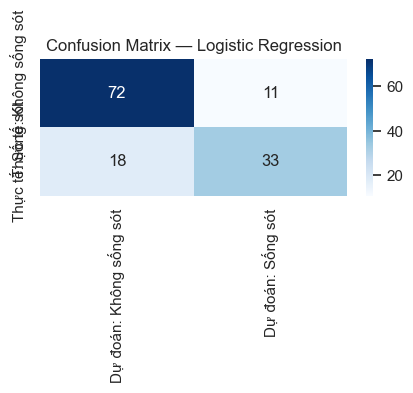

In [18]:
logit = LogisticRegression(max_iter=1000, random_state=42)
logit.fit(Xtr, y_train)

y_pred_logit = logit.predict(Xte)          # nhãn 0/1
y_proba_logit = logit.predict_proba(Xte)[:, 1]  # xác suất sống sót

print("Vài xác suất dự đoán đầu tiên:", y_proba_logit[:5].round(3))
print("Vài nhãn dự đoán đầu tiên    :", y_pred_logit[:5])

# Đánh giá
acc_logit = accuracy_score(y_test, y_pred_logit)
prec_logit = precision_score(y_test, y_pred_logit)
rec_logit = recall_score(y_test, y_pred_logit)
f1_logit = f1_score(y_test, y_pred_logit)
cm_logit = confusion_matrix(y_test, y_pred_logit)

print("=== Đánh giá Logistic Regression trên tập test ===")
print(f"Accuracy : {acc_logit:.4f}")
print(f"Precision: {prec_logit:.4f}")
print(f"Recall   : {rec_logit:.4f}")
print(f"F1-score : {f1_logit:.4f}")

# Trực quan hóa Confusion Matrix bằng heatmap
plt.figure(figsize=(4.5, 3.8))
sns.heatmap(cm_logit, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Dự đoán: Không sống sót","Dự đoán: Sống sót"],
            yticklabels=["Thực tế: Không sống sót","Thực tế: Sống sót"])
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/logit_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.2. Huấn luyện Linear Regression (dùng để phân loại, cần threshold)

`LinearRegression` không có khái niệm "xác suất" hay chặn trong [0,1] — nó chỉ tìm đường thẳng/siêu phẳng khớp `y` tốt nhất theo **MSE**. Vì `Survived` chỉ có 2 giá trị (0/1), ta ép mô hình hồi quy này đóng vai "phân loại" bằng cách:

1. Train bình thường như một bài regression (target là 0/1).
2. Dự đoán ra giá trị **liên tục** (có thể âm hoặc >1 — không phải xác suất thật).
3. **Threshold tại 0.5**: `pred >= 0.5` → lớp 1, ngược lại → lớp 0.

In [16]:
linreg = LinearRegression()
linreg.fit(Xtr, y_train)

raw_pred_linreg = linreg.predict(Xte)      # giá trị liên tục, KHÔNG phải xác suất
y_pred_linreg = (raw_pred_linreg >= 0.5).astype(int)

print("Khoảng giá trị dự đoán thô:", raw_pred_linreg.min().round(3), "->", raw_pred_linreg.max().round(3))
print("(Chú ý: có giá trị < 0 hoặc > 1 — vô nghĩa nếu hiểu là xác suất)")
print("Vài nhãn sau khi threshold 0.5:", y_pred_linreg[:5])

Khoảng giá trị dự đoán thô: -0.224 -> 1.057
(Chú ý: có giá trị < 0 hoặc > 1 — vô nghĩa nếu hiểu là xác suất)
Vài nhãn sau khi threshold 0.5: [1 0 1 0 0]


### 9.3. So sánh kết quả

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc_linreg = accuracy_score(y_test, y_pred_linreg)
prec_linreg = precision_score(y_test, y_pred_linreg)
rec_linreg = recall_score(y_test, y_pred_linreg)
f1_linreg = f1_score(y_test, y_pred_linreg)
cm_linreg = confusion_matrix(y_test, y_pred_linreg)

comparison = pd.DataFrame({
    "Chỉ số": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Logistic Regression": [acc_logit, prec_logit, rec_logit, f1_logit],
    "Linear Regression": [acc_linreg, prec_linreg, rec_linreg, f1_linreg]
})
comparison = comparison.set_index("Chỉ số")
print("BẢNG SO SÁNH HAI MÔ HÌNH")
display(comparison)



BẢNG SO SÁNH HAI MÔ HÌNH


,Logistic Regression,Linear Regression
Chỉ số,,
Accuracy,0.783582,0.761194
Precision,0.750000,0.702128
Recall,0.647059,0.647059
F1-score,0.694737,0.673469


### So sánh Linear Regression và Logistic Regression cho bài toán phân loại

**Logistic Regression** là mô hình được thiết kế dành riêng cho **bài toán phân loại nhị phân (Binary Classification)**, chẳng hạn như dự đoán một hành khách **sống sót** hay **không sống sót**. Mô hình sử dụng **hàm sigmoid** để chuyển đầu ra thành **xác suất trong khoảng từ 0 đến 1**, giúp việc phân loại trở nên trực quan và phù hợp với bản chất của bài toán.

Trong khi đó, **Linear Regression** được xây dựng để giải quyết **bài toán hồi quy (Regression)**, với mục tiêu dự đoán **giá trị liên tục**. Khi áp dụng vào bài toán phân loại, mô hình có thể tạo ra các giá trị **nhỏ hơn 0 hoặc lớn hơn 1**, không thể xem là xác suất. Việc sử dụng một ngưỡng (ví dụ **0.5**) để phân loại chỉ là cách khắc phục tạm thời và thường không mang lại kết quả tối ưu.

### Kết luận

Đối với bài toán dự đoán **hành khách có sống sót hay không**, **Logistic Regression** là lựa chọn phù hợp hơn vì:

- Được thiết kế chuyên biệt cho bài toán phân loại nhị phân.
- Đầu ra là xác suất trong khoảng **[0, 1]**, dễ diễn giải.
- Có thể sử dụng ngưỡng (thường là **0.5**) để đưa ra quyết định phân loại.
- Cho kết quả ổn định, chính xác và đáng tin cậy hơn so với **Linear Regression** trong các bài toán phân loại.